# Análise da métrica Reception Ability Index

In [1]:
# Configurações básicas e imports
import sys
import os
sys.path.insert(0, os.path.abspath('../'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

from utils.utils import plot_reception_on_pitch, draw_pitch, add_reception_legend, reception_title

# Configurar estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

/Users/goncalo.rodrigues9/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/21/7hv4zdjs1xg_628k1767wlpc0000gn/T/matplotlib-whb55jeg because there was an issue with the default path (/Users/goncalo.rodrigues9/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.
/Users/goncalo.rodrigues9/Desktop/SC Braga/GR/360_Statsbomb_Metrics/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Carregar os dados de eventos e a métrica processada
events = pd.read_parquet("../data/processed/events.parquet")
rai_df = pd.read_parquet("../data/processed/reception_ability_index.parquet")
matches = pd.read_parquet("../data/processed/matches.parquet")

# Visualização da métrica

In [3]:
# Ordenar as receções pelo score do RAI de forma decrescente
rai_sorted = rai_df.sort_values(by="score", ascending=False)

def view_reception(rank_idx):
    row = rai_sorted.iloc[rank_idx]
    fig, ax = plt.subplots(figsize=(11, 7.5))
    
    # Título gerado automaticamente com todos os detalhes da métrica remota/local
    title = f"Rank #{rank_idx + 1} | " + reception_title(row, matches)
    
    plot_reception_on_pitch(ax, row, events, title=title)
    add_reception_legend(fig, anchor=(0.5, -0.04))

slider = widgets.IntSlider(min=0, max=100, step=1, value=0, description='Rank (RAI):', layout=widgets.Layout(width='65%'))
widgets.interactive(view_reception, rank_idx=slider)


interactive(children=(IntSlider(value=0, description='Rank (RAI):', layout=Layout(width='65%')), Output()), _d…

O visualizador interativo permite renderizar no campo qualquer um dos lances de receção avaliados no Euro 2024. Neste caso foram filtradas as 100 receções com maior score.

No gráfico:
  - O **polígono verde** representa a área útil de Voronoi do recetor **limitada ao interior do convex hull** defensivo adversário, correspondendo ao espaço potencialmente controlável pelo jogador dentro da estrutura defensiva.
  
  - O **polígono vermelho tracejado** delimita o convex hull defensivo adversário, o que represneta a estrutura espacial do bloco defensivo no momento da receção.
  
  - O **círculo pontilhado vermelho** representa o raio de densidade de 3 metros ao redor do jogador, utilizado para calcular a pressão defensiva local.
  
  - O **losango vermelho** corresponde ao adversário mais próximo e permite visualizar a pressão direta exercida sobre o jogador.
  
  - Os **círculos verdes claros** representam os colegas de equipa do recetor.
  
  - Os **círculos vermelhos** representam os jogadores adversários.
  
  - O **círculo amarelo** representa o guarda-redes adversário.
  
  - O jogador destacado corresponde ao recetor da bola analisado pela métrica.

No cabeçalho do gráfico são ainda apresentados:
  - o valor final do `RAI`
  - o ranking da receção dentro do dataset
  - a área útil de Voronoi
  - a densidade defensiva local
  - a distância ao defensor mais próximo
  - o valor do `Difficulty Context`

### Análise de Distribuições da Métrica

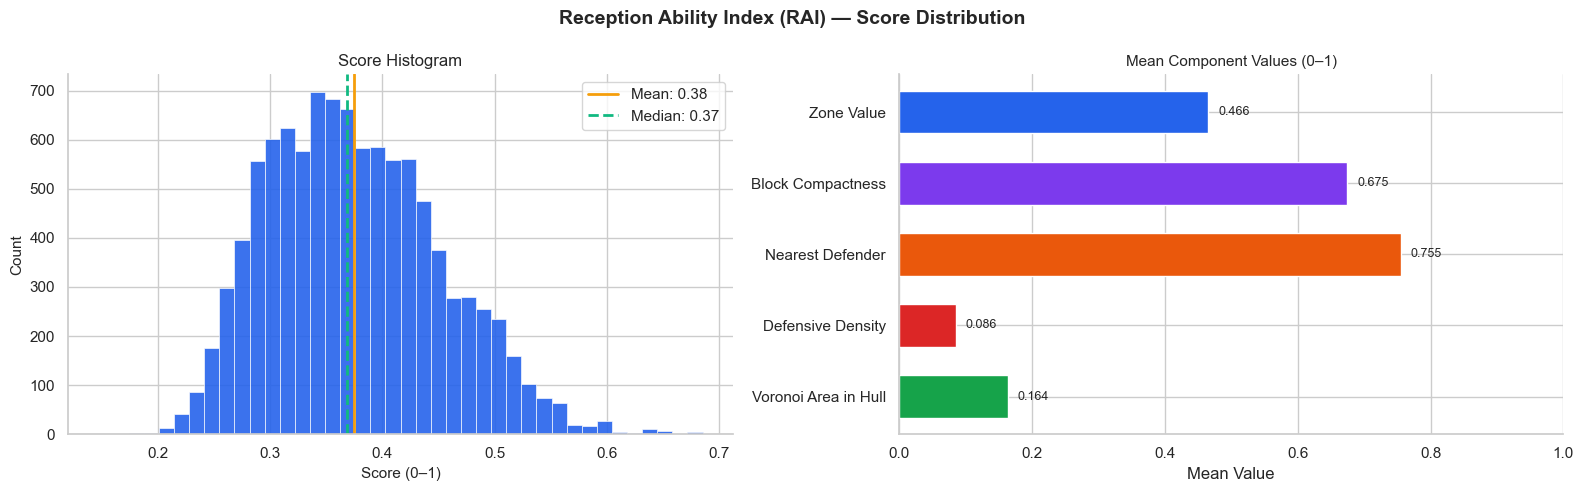

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Reception Ability Index (RAI) — Score Distribution', fontsize=14, fontweight='bold')

# Histograma dos scores RAI
ax = axes[0]
ax.hist(rai_df['score'], bins=40, color='#2563eb', edgecolor='white', linewidth=0.5, alpha=0.9)
ax.axvline(rai_df['score'].mean(), color='#f59e0b', linewidth=2, label=f"Mean: {rai_df['score'].mean():.2f}")
ax.axvline(rai_df['score'].median(), color='#10b981', linewidth=2, linestyle='--', label=f"Median: {rai_df['score'].median():.2f}")
ax.set_xlabel('Score (0–1)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Score Histogram')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gráfico horizontal — média dos componentes
ax2 = axes[1]
components = ['voronoi_area_norm', 'density_norm', 'nearest_defender_norm', 'hull_area_norm', 'zone_value']
labels = ['Voronoi Area in Hull', 'Defensive Density', 'Nearest Defender', 'Block Compactness', 'Zone Value']
colors = ['#16a34a', '#dc2626', '#ea580c', '#7c3aed', '#2563eb']
means = [rai_df[c].mean() for c in components]
bars = ax2.barh(labels, means, color=colors, edgecolor='white', height=0.6)
ax2.set_title('Mean Component Values (0–1)', fontsize=11)
ax2.set_xlabel('Mean Value')
ax2.set_xlim(0, 1)
for bar, val in zip(bars, means):
    ax2.text(
        bar.get_width() + 0.015,
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}',
        va='center',
        fontsize=9
    )

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

O histograma apresenta a distribuição global dos scores do Reception Ability Index (RAI) para todas as receções analisadas. Observa-se uma concentração significativa dos valores entre aproximadamente 0.30 e 0.45, indicando que a maioria das receções ocorre em contextos de dificuldade e espaço intermédios. A proximidade entre média (0.38) e mediana (0.37) sugere uma distribuição relativamente equilibrada, embora exista uma ligeira cauda à direita associada a receções realizadas em contextos espaciais mais favoráveis ou sob maior dificuldade contextual.

O gráfico de barras apresenta o valor médio das diferentes componentes utilizadas no cálculo do RAI. Verifica-se que as variáveis associadas à pressão direta e compactação defensiva (Nearest Defender e Block Compactness) apresentam os valores médios mais elevados, indicando que grande parte das receções ocorre em contextos de elevada proximidade defensiva e blocos relativamente compactos. Por outro lado, a Voronoi Area in Hull e a Defensive Density apresentam médias inferiores, sugerindo que o espaço útil disponível dentro da estrutura defensiva tende a ser reduzido e altamente condicionado pela ocupação espacial adversária.

# Análise Euro 2024

# Turquia 3–1 Geórgia

O confronto entre a Turquia e a Geórgia destaca-se como um dos jogos mais intensos e disputados do Euro 2024 devido ao seu ritmo frenético de transições. Num ambiente de jogo tão vertical e caótico, os jogadores foram constantemente obrigados a receber a bola sob forte pressão defensiva imediata (alta densidade local e marcação apertada) dentro do bloco adversário; assim, o RAI permite-nos quantificar e identificar com precisão quais os atletas que demonstraram melhor inteligência espacial e qualidade técnica para encontrar e explorar o espaço defensivo adversário.

In [24]:
MATCH_ID = 3938639
match_df = rai_df[rai_df['match_id'] == MATCH_ID].copy()
m_info = matches[matches['match_id'] == MATCH_ID].iloc[0]

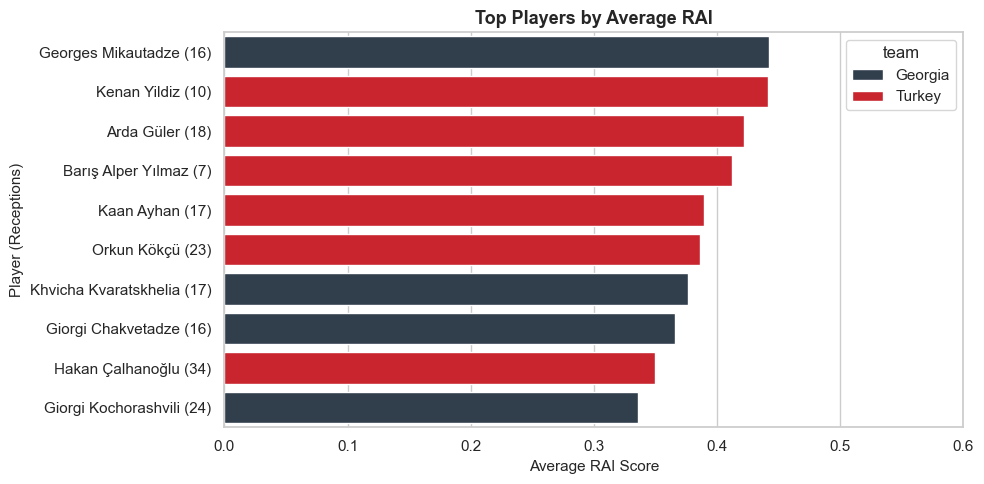

In [25]:
# Definir as cores oficiais das duas equipas para os gráficos
team_colors = {
    "Turkey": "#E30A17",   # Red
    "Georgia": "#2C3E50"   # Dark Blue
}

# Agrupar por jogador e equipa
player_stats_match = match_df.groupby(['player', 'team']).agg(
    mean_rai=('score', 'mean'),
    receptions_count=('score', 'count')
).reset_index()

# Filtrar apenas jogadores com mais de 5 receções
player_stats_match = player_stats_match[
    player_stats_match['receptions_count'] > 5
].copy()

# Adicionar total de receções ao nome do jogador
player_stats_match['player_label'] = (
    player_stats_match['player'] +
    ' (' +
    player_stats_match['receptions_count'].astype(str) +
    ')'
)

# Ordenar por maior média de RAI
top_players_match = player_stats_match.sort_values(
    by='mean_rai',
    ascending=False
)

# Criar gráfico
plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_players_match.head(10),
    x='mean_rai',
    y='player_label',
    hue='team',
    palette=team_colors,
    dodge=False
)

plt.title(
    "Top Players by Average RAI",
    fontsize=13,
    fontweight='bold'
)

plt.xlabel("Average RAI Score", fontsize=11)
plt.ylabel("Player (Receptions)", fontsize=11)

plt.xlim(0, 0.6)

plt.tight_layout()
plt.show()

Observa-se que jogadores como Georges Mikautadze, Kenan Yildiz e Arda Güler apresentam os valores médios de RAI mais elevados, indicando elevada capacidade para receber a bola em contextos espacialmente vantajosos e/ou sob maior dificuldade contextual. Em particular, estes jogadores demonstraram consistência em encontrar espaço útil dentro da estrutura defensiva adversária, recebendo frequentemente em zonas relevantes apesar da proximidade defensiva e compactação do bloco.

Hakan Çalhanoğlu e Orkun Kökçü apresentam um número elevado de receções provavelmente devido ao seu papel na construção, mas com médias de RAI ligeiramente inferiores relativamente a jogadores mais verticais ou posicionados entre linhas. Isto sugere que parte das suas receções ocorreu em contextos menos pressionados ou em zonas de menor valor espacial.

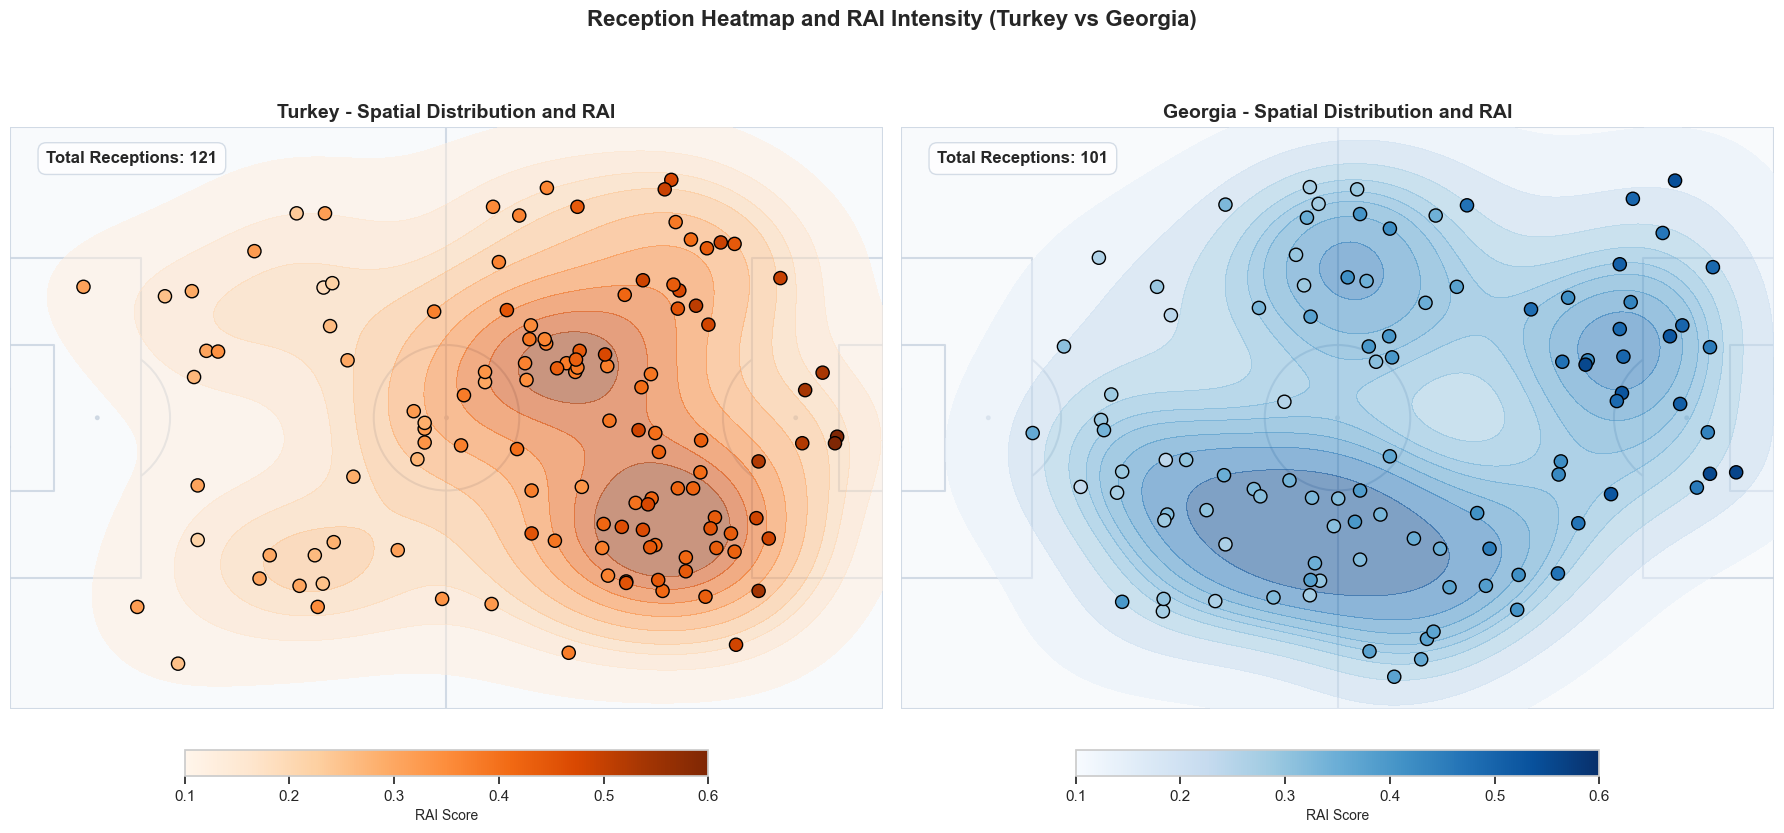

In [26]:
# Filtrar os dados de receções de cada equipa
turkey_df = match_df[match_df['team'] == 'Turkey']
georgia_df = match_df[match_df['team'] == 'Georgia']

# Criar a figura com dois subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Subplot 1: Turkey
ax = axes[0]
draw_pitch(ax, bg='#f8fafc', line_color='#cbd5e1')

if len(turkey_df) > 0:
    # Heatmap de densidade
    sns.kdeplot(
        x=turkey_df['rec_x'], 
        y=turkey_df['rec_y'], 
        fill=True, 
        thresh=0.05, 
        cmap='Oranges', 
        alpha=0.5, 
        ax=ax,
        warn_singular=False
    )

    # Scatter plot individual colorido pelo valor do RAI
    sc1 = ax.scatter(
        turkey_df['rec_x'], 
        turkey_df['rec_y'], 
        c=turkey_df['score'], 
        cmap='Oranges', 
        edgecolors='black', 
        s=90, 
        zorder=3,
        vmin=0.1,
        vmax=0.6
    )

    # Adicionar colorbar
    cbar1 = plt.colorbar(sc1, ax=ax, shrink=0.6, orientation='horizontal', pad=0.05)
    cbar1.set_label('RAI Score', fontsize=10)

# Indicador do número total de receções
ax.text(
    5, 75,
    f"Total Receptions: {len(turkey_df)}",
    fontsize=12,
    fontweight='bold',
    bbox=dict(
        facecolor='white',
        alpha=0.8,
        edgecolor='#cbd5e1',
        boxstyle='round,pad=0.5'
    )
)

ax.set_title("Turkey - Spatial Distribution and RAI", fontsize=14, fontweight='bold')
ax.set_xlim(0, 120)
ax.set_ylim(0, 80)


# Subplot 2: Georgia
ax = axes[1]
draw_pitch(ax, bg='#f8fafc', line_color='#cbd5e1')

if len(georgia_df) > 0:
    # Heatmap de densidade
    sns.kdeplot(
        x=georgia_df['rec_x'], 
        y=georgia_df['rec_y'], 
        fill=True, 
        thresh=0.05, 
        cmap='Blues', 
        alpha=0.5, 
        ax=ax,
        warn_singular=False
    )

    # Scatter plot individual colorido pelo valor do RAI
    sc2 = ax.scatter(
        georgia_df['rec_x'], 
        georgia_df['rec_y'], 
        c=georgia_df['score'], 
        cmap='Blues', 
        edgecolors='black', 
        s=90, 
        zorder=3,
        vmin=0.1,
        vmax=0.6
    )

    # Adicionar colorbar
    cbar2 = plt.colorbar(sc2, ax=ax, shrink=0.6, orientation='horizontal', pad=0.05)
    cbar2.set_label('RAI Score', fontsize=10)

# Indicador do número total de receções
ax.text(
    5, 75,
    f"Total Receptions: {len(georgia_df)}",
    fontsize=12,
    fontweight='bold',
    bbox=dict(
        facecolor='white',
        alpha=0.8,
        edgecolor='#cbd5e1',
        boxstyle='round,pad=0.5'
    )
)

ax.set_title("Georgia - Spatial Distribution and RAI", fontsize=14, fontweight='bold')
ax.set_xlim(0, 120)
ax.set_ylim(0, 80)

# Título principal da figura
plt.suptitle(
    "Reception Heatmap and RAI Intensity (Turkey vs Georgia)",
    fontsize=16,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()
plt.show()

O gráfico apresenta a distribuição espacial das receções avaliadas pelo Reception Ability Index para Turquia e Geórgia, combinando informação de densidade espacial das receções com a intensidade média do score associado a cada ação. As zonas mais escuras do heatmap representam áreas do campo onde existe maior concentração de receções, enquanto a intensidade da cor dos pontos reflete o valor do RAI, isto é, a qualidade contextual dessas receções em termos de espaço disponível e dificuldade defensiva.

No caso da Turquia, observa-se uma elevada concentração de receções no corredor interior direito e em zonas intermédias do meio-campo ofensivo. Além da elevada densidade espacial nessas regiões, vários pontos apresentam intensidade elevada de RAI, sugerindo que a equipa conseguiu receber frequentemente a bola em contextos espacialmente vantajosos dentro da estrutura defensiva adversária. Isto pode indicar boa ocupação dos half-spaces e capacidade para encontrar jogadores entre linhas mesmo perante pressão defensiva.

Já a Geórgia apresenta uma distribuição espacial mais dispersa, com receções relevantes distribuídas entre corredores laterais e zonas mais recuadas. Embora existam algumas ações de elevada intensidade de RAI, a concentração dos scores altos é menos consistente em zonas centrais de progressão. O mapa sugere uma circulação mais fragmentada e menos sustentada em zonas interiores de pressão, com maior dependência de receções exteriores ao bloco.

# Análise Competição

Para encontrar os melhores recetores de bola do torneio, agrupamos as métricas por jogador, exigindo um mínimo de **15 receções no bloco adversário** para garantir consistência e relevância.

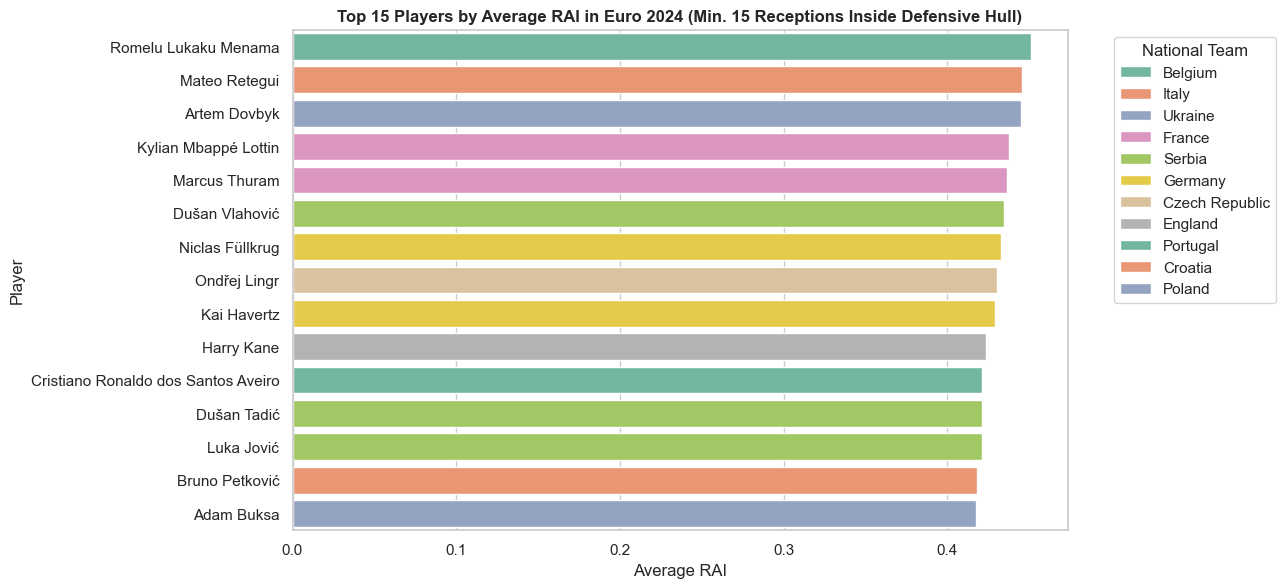

In [27]:
# calcular stats dos jogadores
player_stats = (
    rai_df.groupby(['player', 'team'])
    .agg(
        n_rececoes=('score', 'count'),
        rai_medio=('score', 'mean'),
        voronoi_medio=('voronoi_area', 'mean'),
        dificuldade_media=('difficulty_context', 'mean')
    )
    .reset_index()
)

# Filtrar pelo volume mínimo de 15 receções
player_stats_filtered = player_stats[
    player_stats['n_rececoes'] >= 15
].copy()

# Top 15 jogadores por RAI médio
top_players = player_stats_filtered.nlargest(15, 'rai_medio')

plt.figure(figsize=(10, 6.5))

sns.barplot(
    data=top_players, 
    x='rai_medio', 
    y='player', 
    hue='team', 
    dodge=False, 
    palette='Set2'
)

plt.title(
    'Top 15 Players by Average RAI in Euro 2024 (Min. 15 Receptions Inside Defensive Hull)',
    fontsize=12,
    fontweight='bold'
)

plt.xlabel('Average RAI')
plt.ylabel('Player')

plt.legend(
    title='National Team',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

Observa-se que a maioria dos jogadores presentes na lista corresponde a avançados ou atacantes móveis com forte capacidade física, como Lukaku, Dovbyk, Retegui, Kane ou Vlahović, jogadores frequentemente expostos a contextos de elevada pressão espacial e contacto físico dentro do bloco defensivo.

muitos destes jogadores combinam:

- capacidade física;
- proteção de bola;
- agressividade no ataque à profundidade;
- presença entre centrais;
- receção orientada em espaços reduzidos.

Além disso, vários atletas pertencem a seleções de topo. Isto sugere que equipas com maior domínio territorial e capacidade de instalação ofensiva conseguem gerar mais situações de receção em zonas avançadas e congestionadas do campo. Os resultados reforçam a ideia de que o RAI está efetivamente a capturar a capacidade de receber a bola sob pressão e dentro de estruturas defensivas compactas.

# Perfis Táticos dos Recetores

Ao cruzar **Espaço Útil no Bloco** (`voronoi_area_norm`) no eixo Y com a **Dificuldade Contextual** (`difficulty_context`) no eixo X, dividimos as receções em quatro perfis táticos:

1. **Advanced Space Receiver**
   (Muito espaço + Média/Alta dificuldade e receções em zonas avançadas):  
   Jogadores capazes de encontrar e atacar espaço livre ou pockets entre linhas apesar da pressão defensiva.

2. **Pressured Target**  
   (Pouco espaço + Altíssima dificuldade e receções sob marcação cerrada em zonas avançadas):  
   Jogadores utilizados como referência ofensiva ou apoio sob pressão, capazes de receber em contextos altamente compactos e pressionados.

3. **Free-Space Receiver**  
   (Muito espaço + Baixa dificuldade e receções em zonas recuadas/intermédias):  
   Jogadores que recebem com elevada liberdade espacial, frequentemente em momentos de circulação, fora das principais zonas de pressão ou através de boa capacidade para escapar à densidade defensiva.

4. **Neutral / Peripheral**
   (Pouco espaço + Baixa dificuldade e receções em zonas recuadas):  
   Receções de baixo impacto espacial dentro do bloco, geralmente sem criação de vantagem relevante ou desorganização da estrutura defensiva adversária.

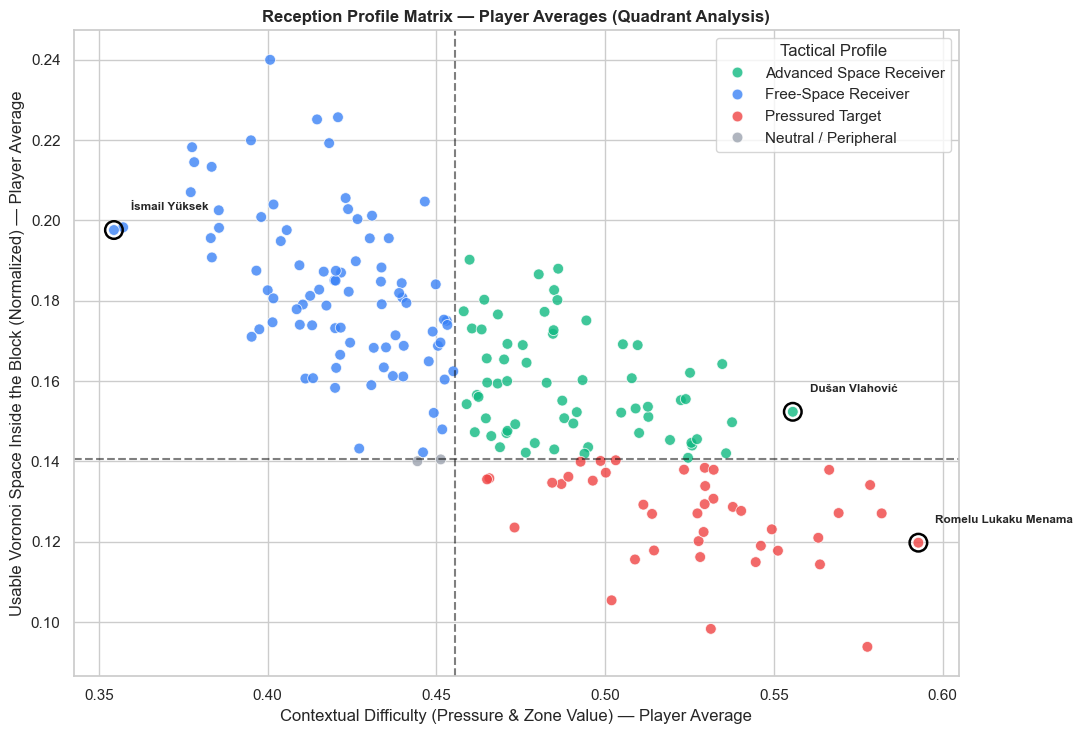

,player,team,reception_profile,difficulty_context,voronoi_area_norm,n_receptions,distance_from_median_cross
348,Romelu Lukaku Menama,Belgium,Pressured Target,0.592833,0.119755,43,0.138875
425,İsmail Yüksek,Turkey,Free-Space Receiver,0.354467,0.197610,25,0.116012
95,Dušan Vlahović,Serbia,Advanced Space Receiver,0.555618,0.152349,23,0.100756


In [28]:
# Medianas calculadas sobre os eventos raw (centro fixo da matriz)
v_median = rai_df['voronoi_area_norm'].median()
d_median = rai_df['difficulty_context'].median()

# Classificar o perfil com base na média do jogador
def classify_profile(row):
    v = row['voronoi_area_norm']
    d = row['difficulty_context']
    if v >= v_median and d >= d_median:
        return 'Advanced Space Receiver'
    elif v < v_median and d >= d_median:
        return 'Pressured Target'
    elif v >= v_median and d < d_median:
        return 'Free-Space Receiver'
    else:
        return 'Neutral / Peripheral'

# Agregar para médias por jogador (1 ponto por jogador)
player_profile_df = (
    rai_df
    .groupby(['player', 'team'])
    .agg(
        difficulty_context=('difficulty_context', 'mean'),
        voronoi_area_norm=('voronoi_area_norm', 'mean'),
        n_receptions=('score', 'count')
    )
    .reset_index()
)

# Filtrar jogadores com mínimo de 15 receções
player_profile_df = player_profile_df[
    player_profile_df['n_receptions'] >= 15
].copy()

# Classificar a média de cada jogador
player_profile_df['reception_profile'] = player_profile_df.apply(classify_profile, axis=1)

# Calcular distância ao cruzamento das medianas (para destacar outliers)
player_profile_df['distance_from_median_cross'] = np.sqrt(
    (player_profile_df['difficulty_context'] - d_median) ** 2 +
    (player_profile_df['voronoi_area_norm'] - v_median) ** 2
)

# Jogador mais afastado por perfil (excluindo Neutral)
non_neutral_df = player_profile_df[
    player_profile_df['reception_profile'] != 'Neutral / Peripheral'
].copy()

top_points_by_profile = (
    non_neutral_df
    .sort_values(['reception_profile', 'distance_from_median_cross'], ascending=[True, False])
    .groupby('reception_profile')
    .head(1)
)

plt.figure(figsize=(11, 7.5))

sns.scatterplot(
    data=player_profile_df,
    x='difficulty_context',
    y='voronoi_area_norm',
    hue='reception_profile',
    palette={
        'Advanced Space Receiver': '#10b981',
        'Pressured Target': '#ef4444',
        'Free-Space Receiver': '#3b82f6',
        'Neutral / Peripheral': '#9ca3af'
    },
    alpha=0.8,
    s=60
)

# Linhas medianas divisórias
plt.axvline(d_median, color='black', linestyle='--', alpha=0.5)
plt.axhline(v_median, color='black', linestyle='--', alpha=0.5)

# Destacar o outlier mais afastado de cada perfil
for _, row in top_points_by_profile.iterrows():
    x = row['difficulty_context']
    y = row['voronoi_area_norm']
    plt.scatter(x, y, s=160, facecolors='none', edgecolors='black', linewidths=1.8, zorder=5)
    plt.text(x + 0.005, y + 0.005, row['player'], fontsize=8.5, fontweight='bold', zorder=6)

plt.title('Reception Profile Matrix — Player Averages (Quadrant Analysis)', fontsize=12, fontweight='bold')
plt.xlabel('Contextual Difficulty (Pressure & Zone Value) — Player Average')
plt.ylabel('Usable Voronoi Space Inside the Block (Normalized) — Player Average')
plt.legend(title='Tactical Profile', loc='upper right')
plt.tight_layout()
plt.show()

display(
    top_points_by_profile[[
        'player', 'team', 'reception_profile',
        'difficulty_context', 'voronoi_area_norm',
        'n_receptions', 'distance_from_median_cross'
    ]].sort_values('distance_from_median_cross', ascending=False)
)


O gráfico apresenta uma matriz de perfis de receção construída a partir de duas dimensões do *Reception Ability Index (RAI)*. No eixo horizontal encontra-se o *Contextual Difficulty*, que mede a dificuldade da receção em função da pressão defensiva, da compactação do bloco e do valor estratégico da zona. No eixo vertical está representado o *Usable Voronoi Space Inside the Block*, que quantifica o espaço útil disponível para o jogador dentro do bloco defensivo adversário.

As linhas tracejadas assinalam as medianas globais de ambas as variáveis, dividindo o gráfico em quatro perfis distintos de receção.

No quadrante superior direito (*Advanced Space Receiver*) surgem os jogadores que conseguem receber com espaço disponível mesmo em cenários de elevada dificuldade defensiva. Este perfil reflete uma forte capacidade para encontrar espaços entre linhas e criar condições favoráveis de receção dentro de estruturas defensivas compactas. O exemplo mais extremo é Vlahovic, cuja ação combina simultaneamente valores muito elevados de espaço útil e dificuldade contextual.

O quadrante inferior direito (*Pressured Target*) reúne receções realizadas sob forte pressão e com reduzido espaço disponível. Trata-se frequentemente de avançados de referência ou jogadores utilizados como apoio frontal, capazes de servir como ponto de ligação da equipa em situações de elevada densidade defensiva. Lukaku destaca-se como o caso mais extremo deste perfil.

No quadrante superior esquerdo (*Free-Space Receiver*) encontram-se jogadores que recebem com bastante espaço disponível em contextos relativamente menos exigentes do ponto de vista defensivo. Estas ações estão normalmente associadas a momentos de circulação, apoios exteriores ou movimentos que permitem escapar à pressão e explorar zonas menos congestionadas. Yuksek surge como o exemplo mais evidente deste perfil, apresentando um nível de espaço útil claramente acima da média observada no torneio.

Por último, o quadrante inferior esquerdo (*Neutral / Peripheral*) agrega receções caracterizadas por baixos níveis de espaço e de dificuldade contextual. Em geral, correspondem a ações mais periféricas e com menor influência na organização espacial do jogo.
